#📌 Extracción

In [1]:
import pandas as pd

#Importacion de los datos directamente desde la api
api = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
#Conversion de la data en un dataframe
df = pd.read_json(api)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [2]:
#dimensionamiento del dataset
df.shape

(7267, 6)

In [3]:
df.describe()

,customerID,Churn,customer,phone,internet,account
count,7267,7267,7267,7267,7267,7267
unique,7267,3,891,3,129,6931
top,9995-HOTOH,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
freq,1,5174,223,3495,1581,6


#📊 Carga y análisis

In [4]:
# Normalizar el data frame columnas que vienen en formato json
customer_df = pd.json_normalize(df['customer'])
phone_df = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df = pd.json_normalize(df['account'])

In [5]:
# Unir todo normalizado en un df
df_final = pd.concat(
    [
        df[['customerID','Churn']],
        customer_df,
        phone_df,
        internet_df,
        account_df
    ],
    # unir todo horizontalmente
    axis=1
)
df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [6]:
#Validacion de que ya no son json
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


#**PARTE 2**
#🛠️ Preparación de los Datos

In [7]:
#Remover columnas inecesarios
df_final.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

In [8]:
df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [9]:
#Encoding
# Se revisara cuáles columnas son de tipo texto para pasarlas a numericas

df_final.select_dtypes(include='object').columns

Index(['customerID', 'Churn', 'gender', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Total'],
      dtype='object')

In [10]:
#One-Hot Encoding, se convierte todo a numeros
df_encoding = pd.get_dummies(df_final, drop_first=True)
df_encoding.head()

,SeniorCitizen,tenure,Charges.Monthly,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,customerID_0014-BMAQU,...,Charges.Total_995.35,Charges.Total_996.45,Charges.Total_996.85,Charges.Total_996.95,Charges.Total_997.65,Charges.Total_997.75,Charges.Total_998.1,Charges.Total_999.45,Charges.Total_999.8,Charges.Total_999.9
0,0,9,65.6,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,9,59.9,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,4,73.9,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,13,98.0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,3,83.9,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [11]:
#verificar tipos de datos
df_encoding.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Columns: 13827 entries, SeniorCitizen to Charges.Total_999.9
dtypes: bool(13824), float64(1), int64(2)
memory usage: 96.0 MB


In [12]:
#Verificación de la Proporción de Cancelación (Churn
#Visualizacion de cantidades enconding
df_encoding['Churn_Yes'].value_counts()

,count
Churn_Yes,
False,5398
True,1869


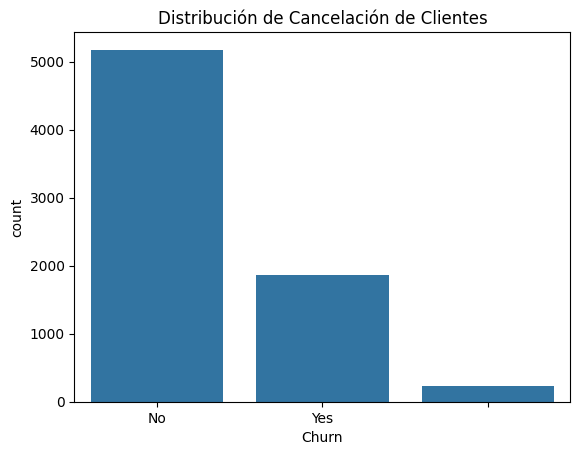

In [13]:
#Grafico seaborn
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df_final)

plt.title("Distribución de Cancelación de Clientes")
plt.show()


#🎯 Correlación y Selección de Variables

In [14]:
df_encoding.shape

(7267, 13827)

In [15]:
#La correlacion se evaluara solo en churn
correlation_churn = df_encoding.apply(
    lambda col: col.corr(df_encoding['Churn_Yes'])
)

correlation_churn = correlation_churn.sort_values(ascending=False)

correlation_churn

,0
Churn_Yes,1.000000
InternetService_Fiber optic,0.300949
PaymentMethod_Electronic check,0.294626
Charges.Monthly,0.189866
PaperlessBilling_Yes,0.186666
...,...
StreamingMovies_No internet service,-0.224051
InternetService_No,-0.224051
Contract_Two year,-0.295138
tenure,-0.344079


In [17]:
# ver las variables más relacionadas con churn
correlation_churn.head()

,0
Churn_Yes,1.000000
InternetService_Fiber optic,0.300949
PaymentMethod_Electronic check,0.294626
Charges.Monthly,0.189866
PaperlessBilling_Yes,0.186666


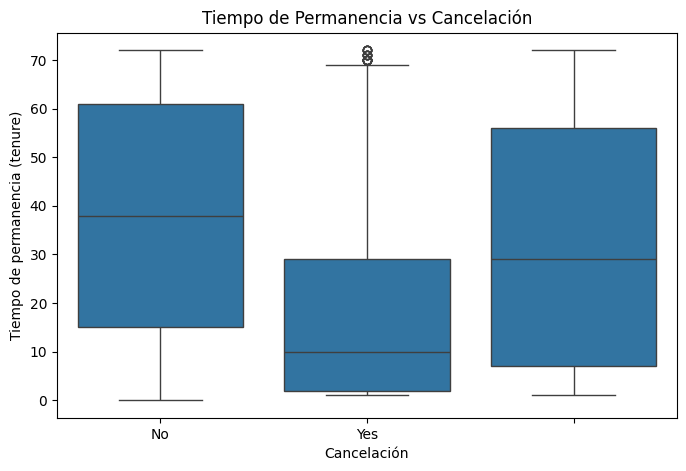

In [20]:
#Visualización 1 — Tiempo de contrato vs Cancelación
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='tenure', data=df_final)

plt.title("Tiempo de Permanencia vs Cancelación")
plt.xlabel("Cancelación")
plt.ylabel("Tiempo de permanencia (tenure)")

plt.show()

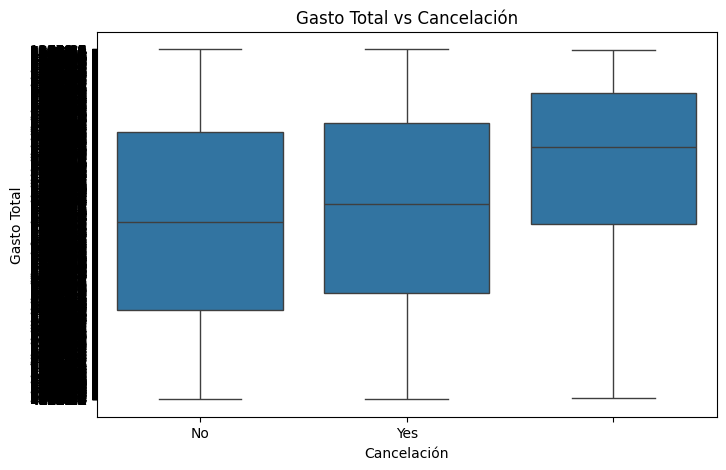

In [22]:
# Visualización 2 — Gasto total vs Cancelación
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='Charges.Total', data=df_final)

plt.title("Gasto Total vs Cancelación")
plt.xlabel("Cancelación")
plt.ylabel("Gasto Total")

plt.show()

#Modelo predictivo

In [24]:
# Separar variables predictoras y variable objetivo
# Variables predictoras
X = df_encoding.drop('Churn_Yes', axis=1)

# Variable objetivo
y = df_encoding['Churn_Yes']

In [26]:
#Dividir datos de entrenamiento y prueba 80 entrenamiento/20 prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [27]:
#Normalizar datos para regresión logística
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
#Modelo 1 — Regresión Logística
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [30]:
#Modelo 2 — Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [31]:
#Importacion de metricas para evaluacion de modelos
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [32]:
#Evaluación modelo Regresión Logística
print("Regresión Logística")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

print(confusion_matrix(y_test, y_pred_log))

Regresión Logística
Accuracy: 0.8954607977991746
Precision: 0.9435483870967742
Recall: 0.6290322580645161
F1 Score: 0.7548387096774194
[[1068   14]
 [ 138  234]]


In [33]:
#Evaluación modelo Random Forest
print("Random Forest")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

Random Forest
Accuracy: 0.9477303988995873
Precision: 0.9302325581395349
Recall: 0.8602150537634409
F1 Score: 0.8938547486033519
[[1058   24]
 [  52  320]]


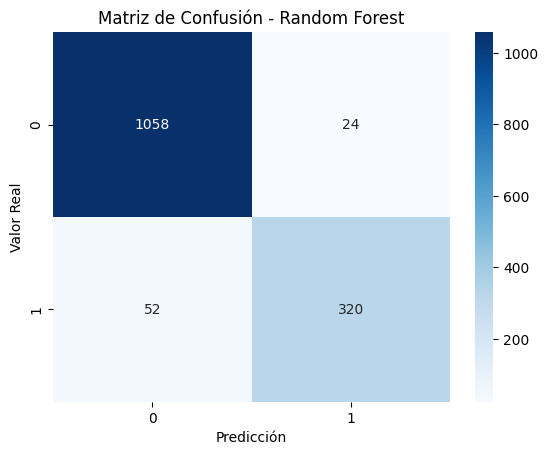

In [34]:
#Visualizar matriz de confusión
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

#Informe de variables y conclusión

## Análisis de Variables y Conclusión

A partir del análisis exploratorio, la correlación y la importancia de variables en los modelos predictivos, se identificó que **tenure (tiempo de permanencia)**, **Charges.Monthly (cargos mensuales)**, **Charges.Total (gasto total)** y **el tipo de contrato** son algunos de los factores que más influyen en la cancelación de clientes. En general, los clientes con **menor tiempo de permanencia, contratos mensuales y mayores cargos mensuales** presentan una mayor probabilidad de cancelar el servicio.

Al comparar los modelos predictivos, **Random Forest mostró un mejor desempeño** que la regresión logística, lo que indica que este modelo logra capturar de mejor manera las relaciones entre las variables del conjunto de datos.

Con base en estos resultados, se recomienda que la empresa implemente **estrategias de retención enfocadas en clientes nuevos**, promueva **contratos de mayor duración** mediante incentivos y evalúe **estrategias de precios o beneficios adicionales**, con el objetivo de reducir la tasa de cancelación y mejorar la fidelización de los clientes.